Question 1 : Intensity Transformations on the Runway Image

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [4]:
#Load Image
img_path = 'images/runway.png'
img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

#Normalize image to [0,1]
img_norm = img / 255.0

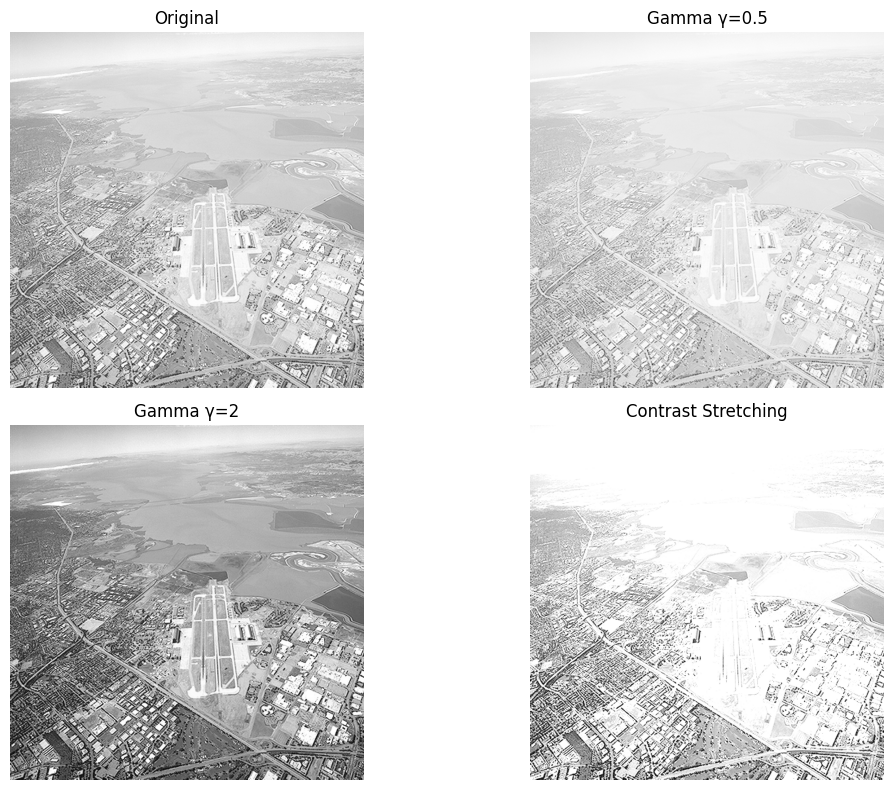

In [5]:
# a) Gamma correction (γ = 0.5)
gamma_05 = np.power(img_norm, 0.5)

# b) Gamma correction (γ = 2)
gamma_2 = np.power(img_norm, 2)

# c) Contrast Stretching (Piecewise function)
r1, r2 = 0.2, 0.8

contrast = np.zeros_like(img_norm)

# Apply piecewise transformation
contrast[img_norm < r1] = 0
mask = (img_norm >= r1) & (img_norm <= r2)
contrast[mask] = (img_norm[mask] - r1) / (r2 - r1)
contrast[img_norm > r2] = 1

# Convert back to [0,255] for display
gamma_05_img = (gamma_05 * 255).astype(np.uint8)
gamma_2_img = (gamma_2 * 255).astype(np.uint8)
contrast_img = (contrast * 255).astype(np.uint8)

# Display results
titles = ["Original", "Gamma γ=0.5", "Gamma γ=2", "Contrast Stretching"]
images = [img, gamma_05_img, gamma_2_img, contrast_img]

plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

Question 2 : Gamma Correction in Lab* Color Space

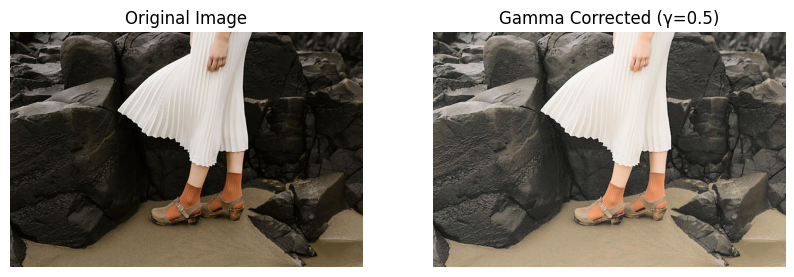

In [6]:
# Load image (BGR)
img_path = "images/highlights_and_shadows.jpg"
img_bgr = cv.imread(img_path)

# Convert to RGB for display
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# Convert to LAB color space
lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)

# Split channels
L, a, b = cv.split(lab)

# Normalize L channel to [0,1]
L_norm = L / 255.0

# -------- Gamma Correction --------
gamma = 0.5   # ✅ chosen gamma value
L_corrected = np.power(L_norm, gamma)

# Scale back to [0,255]
L_corrected = (L_corrected * 255).astype(np.uint8)

# Merge channels back
lab_corrected = cv.merge((L_corrected, a, b))

# Convert back to RGB
img_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2RGB)

# Display results
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_corrected)
plt.title(f"Gamma Corrected (γ={gamma})")
plt.axis('off')

plt.show()

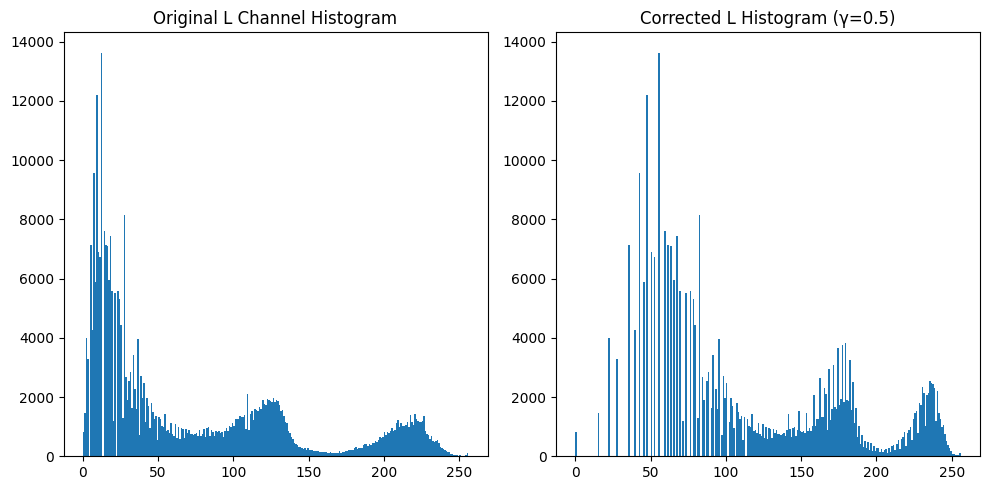

In [7]:
# Histogram of original and corrected L channel

plt.figure(figsize=(10,5))

# Original histogram
plt.subplot(1,2,1)
plt.hist(L.flatten(), bins=256, range=[0,256])
plt.title("Original L Channel Histogram")

# Corrected histogram
plt.subplot(1,2,2)
plt.hist(L_corrected.flatten(), bins=256, range=[0,256])
plt.title(f"Corrected L Histogram (γ={gamma})")

plt.tight_layout()
plt.show()